In [3]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
IMAGE_PATH = "448"

data = []
sample_images = []

for root, folders, files in os.walk(IMAGE_PATH):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            path = os.path.join(root, file)
            img = cv2.imread(path)

            if img is None:
                continue

            # Resize
            img = cv2.resize(img, (128, 128))

            # Grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Basic image features
            mean_brightness = np.mean(gray)
            contrast = np.std(gray)

            dark_ratio = np.mean(gray < 50)
            bright_ratio = np.mean(gray > 200)

            # Canny edge detection
            edges = cv2.Canny(gray, 100, 200)

            edge_count = np.sum(edges > 0)
            edge_density = edge_count / edges.size

            # Get label from folder/file name
            name = (root + file).lower()

            if "non" in name or "normal" in name:
                label = 0
            elif "crack" in name:
                label = 1
            else:
                continue

            data.append([
                mean_brightness,
                contrast,
                dark_ratio,
                bright_ratio,
                edge_count,
                edge_density,
                label
            ])

            sample_images.append((img, gray, edges, label))


columns = [
    "mean_brightness",
    "contrast",
    "dark_ratio",
    "bright_ratio",
    "edge_count",
    "edge_density",
    "label"
]

image_df = pd.DataFrame(data, columns=columns)

print("Total images:", len(image_df))
print("\nClass distribution:")
print(image_df["label"].value_counts())

display(image_df.head())

Total images: 400

Class distribution:
label
1    200
0    200
Name: count, dtype: int64


,mean_brightness,contrast,dark_ratio,bright_ratio,edge_count,edge_density,label
0,122.263977,33.070752,0.005859,0.014465,5580,0.340576,1
1,131.565186,25.482184,0.003418,0.004456,4579,0.279480,1
2,121.076355,31.130490,0.014221,0.010498,4303,0.262634,1
3,130.309143,27.282676,0.002197,0.006592,5507,0.336121,1
4,130.993286,27.639562,0.003357,0.007751,5218,0.318481,1


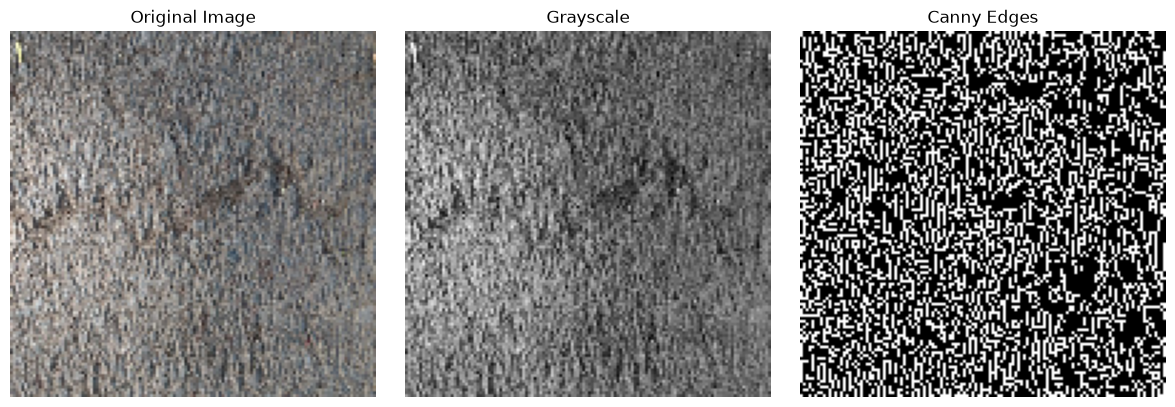

In [5]:
img, gray, edges, label = sample_images[0]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

IMAGE CLASSIFICATION RESULTS
----------------------------
Accuracy : 0.9375
Precision: 0.9487
Recall   : 0.925
F1 Score : 0.9367
Training time : 0.111 seconds
Prediction time: 0.0086 seconds


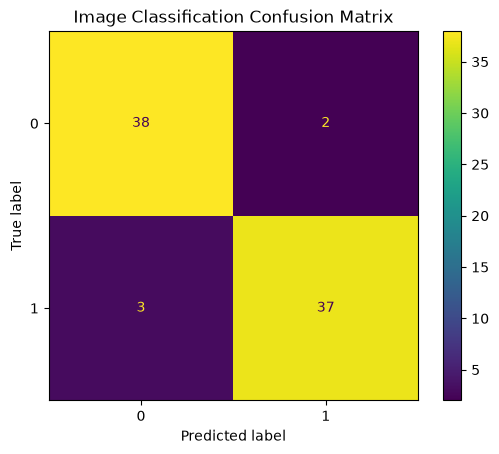

In [6]:
X = image_df.drop("label", axis=1)
y = image_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training time
start = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start

# Prediction time
start = time.time()
pred = model.predict(X_test)
prediction_time = time.time() - start

print("IMAGE CLASSIFICATION RESULTS")
print("----------------------------")
print("Accuracy :", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred), 4))
print("Recall   :", round(recall_score(y_test, pred), 4))
print("F1 Score :", round(f1_score(y_test, pred), 4))
print("Training time :", round(train_time, 4), "seconds")
print("Prediction time:", round(prediction_time, 4), "seconds")

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Image Classification Confusion Matrix")
plt.show()

In [10]:
emails = pd.read_csv("emails.csv", encoding="latin-1")

print("Dataset shape:", emails.shape)
print("\nColumns:")
print(emails.columns.tolist())

display(emails.head())

Dataset shape: (5172, 3002)

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here',

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [11]:
# Prepare email dataset

# Remove email ID
X_text = emails.drop(columns=["Email No.", "Prediction"])

# Target variable
y_text = emails["Prediction"]

print("Number of features:", X_text.shape[1])
print("\nClass distribution:")
print(y_text.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text
)

# Count-based representation
count_model = LogisticRegression(max_iter=1000)

start = time.time()
count_model.fit(X_train, y_train)
count_train_time = time.time() - start

start = time.time()
count_pred = count_model.predict(X_test)
count_prediction_time = time.time() - start

print("\nCOUNT-BASED FEATURES")
print("--------------------")
print("Number of features:", X_train.shape[1])
print("Accuracy :", round(accuracy_score(y_test, count_pred), 4))
print("Precision:", round(precision_score(y_test, count_pred), 4))
print("Recall   :", round(recall_score(y_test, count_pred), 4))
print("F1 Score :", round(f1_score(y_test, count_pred), 4))
print("Training time:", round(count_train_time, 4), "seconds")
print("Prediction time:", round(count_prediction_time, 4), "seconds")

Number of features: 3000

Class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

COUNT-BASED FEATURES
--------------------
Number of features: 3000
Accuracy : 0.9826
Precision: 0.9578
Recall   : 0.9833
F1 Score : 0.9704
Training time: 7.3949 seconds
Prediction time: 0.0601 seconds


In [12]:
from sklearn.feature_extraction.text import TfidfTransformer

# Convert existing word-count features to TF-IDF

tfidf_transformer = TfidfTransformer()

X_train_tfidf = tfidf_transformer.fit_transform(X_train)
X_test_tfidf = tfidf_transformer.transform(X_test)

tfidf_model = LogisticRegression(max_iter=1000)

start = time.time()
tfidf_model.fit(X_train_tfidf, y_train)
tfidf_train_time = time.time() - start

start = time.time()
tfidf_pred = tfidf_model.predict(X_test_tfidf)
tfidf_prediction_time = time.time() - start

print("TF-IDF RESULTS")
print("--------------")
print("Number of features:", X_train_tfidf.shape[1])
print("Accuracy :", round(accuracy_score(y_test, tfidf_pred), 4))
print("Precision:", round(precision_score(y_test, tfidf_pred), 4))
print("Recall   :", round(recall_score(y_test, tfidf_pred), 4))
print("F1 Score :", round(f1_score(y_test, tfidf_pred), 4))
print("Training time:", round(tfidf_train_time, 4), "seconds")
print("Prediction time:", round(tfidf_prediction_time, 4), "seconds")

TF-IDF RESULTS
--------------
Number of features: 3000
Accuracy : 0.9507
Precision: 0.9308
Recall   : 0.8967
F1 Score : 0.9134
Training time: 0.0586 seconds
Prediction time: 0.0012 seconds


TEXT CLASSIFICATION COMPARISON


,Method,Features,Accuracy,Precision,Recall,F1 Score,Train Time,Prediction Time
0,Word Count,3000,0.9826,0.9578,0.9833,0.9704,7.3949,0.0601
1,TF-IDF,3000,0.9507,0.9308,0.8967,0.9134,0.0586,0.0012


<Figure size 500x400 with 0 Axes>

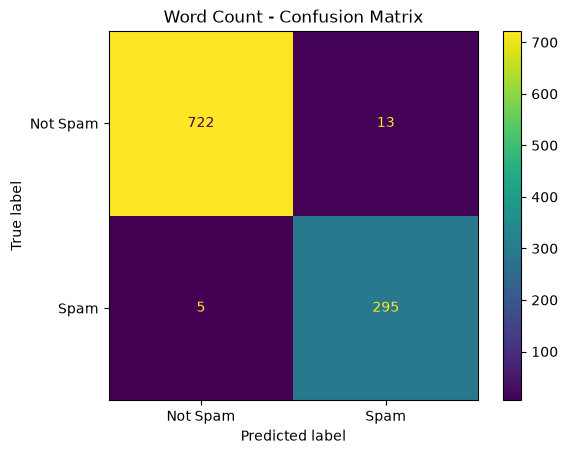

<Figure size 500x400 with 0 Axes>

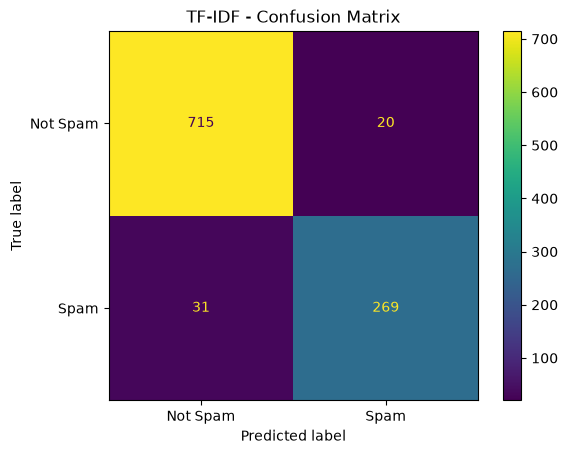

In [13]:
# Compare Count-based features and TF-IDF

print("TEXT CLASSIFICATION COMPARISON")
print("==============================")

results = pd.DataFrame({
    "Method": ["Word Count", "TF-IDF"],
    "Features": [
        X_train.shape[1],
        X_train_tfidf.shape[1]
    ],
    "Accuracy": [
        accuracy_score(y_test, count_pred),
        accuracy_score(y_test, tfidf_pred)
    ],
    "Precision": [
        precision_score(y_test, count_pred),
        precision_score(y_test, tfidf_pred)
    ],
    "Recall": [
        recall_score(y_test, count_pred),
        recall_score(y_test, tfidf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, count_pred),
        f1_score(y_test, tfidf_pred)
    ],
    "Train Time": [
        count_train_time,
        tfidf_train_time
    ],
    "Prediction Time": [
        count_prediction_time,
        tfidf_prediction_time
    ]
})

display(results.round(4))


# Confusion matrices

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    count_pred,
    display_labels=["Not Spam", "Spam"]
)
plt.title("Word Count - Confusion Matrix")
plt.show()


plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tfidf_pred,
    display_labels=["Not Spam", "Spam"]
)
plt.title("TF-IDF - Confusion Matrix")
plt.show()

In [14]:
# Improved TF-IDF representation

improved_tfidf = TfidfTransformer(
    sublinear_tf=True
)

X_train_improved = improved_tfidf.fit_transform(X_train)
X_test_improved = improved_tfidf.transform(X_test)

improved_model = LogisticRegression(
    max_iter=1000
)

start = time.time()
improved_model.fit(X_train_improved, y_train)
improved_train_time = time.time() - start

start = time.time()
improved_pred = improved_model.predict(X_test_improved)
improved_prediction_time = time.time() - start

print("IMPROVED TF-IDF RESULTS")
print("=======================")

print("Number of features:", X_train_improved.shape[1])

print("Accuracy :",
      round(accuracy_score(y_test, improved_pred), 4))

print("Precision:",
      round(precision_score(y_test, improved_pred), 4))

print("Recall   :",
      round(recall_score(y_test, improved_pred), 4))

print("F1 Score :",
      round(f1_score(y_test, improved_pred), 4))

print("Training time:",
      round(improved_train_time, 4), "seconds")

print("Prediction time:",
      round(improved_prediction_time, 4), "seconds")

IMPROVED TF-IDF RESULTS
Number of features: 3000
Accuracy : 0.9855
Precision: 0.9672
Recall   : 0.9833
F1 Score : 0.9752
Training time: 0.0518 seconds
Prediction time: 0.0009 seconds


In [15]:
final_results = pd.DataFrame({
    "Representation": [
        "Word Count",
        "TF-IDF",
        "Improved TF-IDF"
    ],

    "Features": [
        X_train.shape[1],
        X_train_tfidf.shape[1],
        X_train_improved.shape[1]
    ],

    "Accuracy": [
        accuracy_score(y_test, count_pred),
        accuracy_score(y_test, tfidf_pred),
        accuracy_score(y_test, improved_pred)
    ],

    "Precision": [
        precision_score(y_test, count_pred),
        precision_score(y_test, tfidf_pred),
        precision_score(y_test, improved_pred)
    ],

    "Recall": [
        recall_score(y_test, count_pred),
        recall_score(y_test, tfidf_pred),
        recall_score(y_test, improved_pred)
    ],

    "F1 Score": [
        f1_score(y_test, count_pred),
        f1_score(y_test, tfidf_pred),
        f1_score(y_test, improved_pred)
    ],

    "Training Time": [
        count_train_time,
        tfidf_train_time,
        improved_train_time
    ],

    "Prediction Time": [
        count_prediction_time,
        tfidf_prediction_time,
        improved_prediction_time
    ]
})

display(final_results.round(4))

,Representation,Features,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
0,Word Count,3000,0.9826,0.9578,0.9833,0.9704,7.3949,0.0601
1,TF-IDF,3000,0.9507,0.9308,0.8967,0.9134,0.0586,0.0012
2,Improved TF-IDF,3000,0.9855,0.9672,0.9833,0.9752,0.0518,0.0009


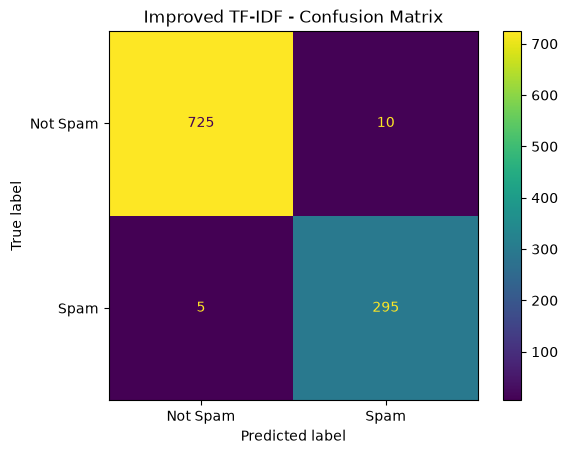

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    improved_pred,
    display_labels=["Not Spam", "Spam"]
)

plt.title("Improved TF-IDF - Confusion Matrix")
plt.show()

FINAL OBSERVATIONS
==================
1. Image features were extracted using brightness, contrast, pixel ratios and Canny edges.
2. A Random Forest classifier was used for image classification.
3. The email dataset already contained word-count features.
4. Logistic Regression was used for spam classification.
5. TF-IDF was applied to the existing word-count representation.
6. An improved TF-IDF representation using sublinear term frequency was also tested.
7. Accuracy, precision, recall, F1-score and computation time were compared.